# AG3 - Actividad Guiada 3
Nombre: Wilson Bello V. <br>
Link:   https://colab.research.google.com/drive/1Pgh1r5k7OSRbTxyAwy1l2vciFiYbHSPd?usp=sharing <br>
Github: https://github.com/xxxxx/AlgoritmosOptimizacion
<br>


### Carga de librerias

Las librerias propuesta al ejecutarlas en el entorno de Google Copab, presentaban conflictos de dependencias. La opción implementada fue trabajar el archivo en forma local, se creo un entorno virtual y allí se instalaron algunas librerias mas actualizadas que no generaron conflictos y se pudo presentar la mejora a la función `genera_vecina_aleatorio`. Se creo archivo requirements_AG3.txt, para consulta y verificación de librerias utilizadas.

In [1]:
"""
Estas son las librerias iniciales del Notebook pero al proceder con su corrida presenta un mensaje de advertencia
de conflictos de dependencias
"""

!pip install requests
!pip install tabulate>=0.9 networkx>=3.0
!pip install tsplib95 --no-deps
!pip install deprecated

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.4-cp313-cp313-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.4-cp313-cp313-win_amd64.whl (107 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached tsplib95-0.7.1-py2.py3-none-any.whl.metadata (6.3 kB)
Using cached tsplib95-0.7.1-py2.py3-none-any.whl (25 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
Using cached deprecated-1.3.1-py2.py3-none-any.whl (11 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsplib95 0.7.1 requires Click>=6.0, which is not installed.
tsplib95 0.7.1 requires Deprecated~=1.2.9, but you have deprecated 1.3.1 which is incompatible.
tsplib95 0.7.1 requires networkx~=2.1, but you have networkx 3.6.1 which is incompatible.
tsplib95 0.7.1 requires tabulate~=0.8.7, but you have tabulate 0.9.0 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install "deprecated==1.2.18" "networkx==2.8.8" "tabulate==0.8.10" click --force-reinstall --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import tsplib95
print(tsplib95.__version__)

0.7.1


In [ ]:
# Ya se tiene instalada la versión correcta deprecated==1.2.18 y si se ejecuta esta celda sin especificar versión, 
# pip instalará la 1.3.1 que es incompatible con tsplib95 y se volverá a tener conflictos.

!pip install deprecated

# Carga de los datos del problema

In [58]:

import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/




('swiss42.tsp', <http.client.HTTPMessage at 0x1a9a2581bf0>)

In [ ]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())


In [60]:
Nodos

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41]

In [61]:
Aristas
# https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),



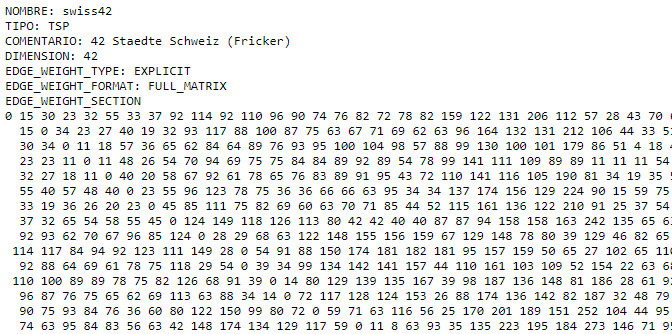

In [62]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(3, 0)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

23

# Funciones basicas


In [63]:
###############################################################################
#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)


print(sol_temporal   )
print(distancia_total(sol_temporal, problem))

[0, 4, 17, 7, 1, 12, 35, 41, 2, 36, 40, 8, 11, 38, 23, 5, 9, 26, 37, 27, 24, 29, 16, 30, 20, 31, 32, 34, 15, 18, 22, 10, 19, 6, 14, 21, 28, 3, 33, 13, 39, 25]
5022


# BUSQUEDA ALEATORIA

In [64]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 50000)

Mejor solución: [0, 32, 4, 27, 5, 30, 24, 22, 31, 1, 28, 33, 34, 17, 35, 36, 29, 20, 39, 8, 2, 7, 18, 26, 25, 12, 11, 10, 40, 9, 19, 16, 3, 6, 13, 21, 37, 15, 14, 38, 23, 41]
Distancia     : 3575


# BUSQUEDA LOCAL

In [65]:
###############################################################################
# BUSQUEDA LOCAL(1 paso)
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3575
Distancia Mejor Solucion Local: 3268


In [66]:
#Busqueda Local(iteraciones):
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(solucion, problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  #solucion_referencia = crear_solucion(Nodos)
  solucion_referencia = solucion
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(nueva_solucion, problem )

En la iteracion  28 , la mejor solución encontrada es: [0, 3, 4, 2, 27, 28, 29, 22, 38, 30, 32, 34, 33, 20, 35, 36, 39, 21, 24, 40, 9, 23, 41, 25, 11, 12, 10, 8, 18, 26, 5, 13, 19, 7, 31, 17, 37, 15, 16, 14, 6, 1]
Distancia     : 1634


### SIMULATED ANNEALING


### <span style="color:orange">Propuesta de mejora a función `genera_vecina_aleatorio`</span>

La función actual selecciona dos nodos aleatorios y los intercambia de posición.<br>
Ejemplo:<br>
Si la solución original es: <span style="color:orange">[0, 1, 2, 3, 4, 5, 0]</span> <br>
Se eligen los nodos: <span style="color:orange">i=2, j=4</span><br>
El Segmento invertido queda: <span style="color:orange">[2, 3, 4]</span> -> <span style="color:orange">[4, 3, 2]</span><br>
Tenemos como resultado:      <span style="color:orange">[0, 1, 4, 3, 2, 5, 0]</span><br>

Solo se intercambio los nodos de las posiciones `i` y `j`, dejando intacto el resto del recorrido. Este movimiento es limitado porque no considera si el intercambio genera o limita cruces en la ruta.

El intercambio de nodos puede generar rutas con `cruces geometricos`, lo que matemáticamente implica recorridos mas largos. Un cruce se presenta cuando dos aristas del recorrido se intersectan.<br>
Ejemplo:<br>

Si la solución original es: <span style="color:orange">[0, 1, 2, 3, 4, 5, 0]</span> <br>
Y se eligen los nodos: <span style="color:orange">i=2, j=4</span><br>
El Segmento invertido queda: <span style="color:orange">[2, 3, 4]</span> -> <span style="color:orange">[4, 3, 2]</span><br>
Tenemos como resultado:      <span style="color:orange">[0, 1, 4, 3, 2, 5, 0]</span><br>

Solo se intercambian los nodos en las posiciones `i` y `j`, dejando intacto el resto del recorrido. Este movimiento es limitado porque no considera si el intercambio genera o elimina cruces en la ruta.

El intercambio simple puede generar rutas con cruces geómetricos, lo que matematicamente implica recorridos mas largos. Un cruce ocurre cuando dos aristas del recorrido se intersectan, como en el siguiente ejemplo:

con cruce &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; sin cruce   

1 ----> 3 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 1 <----- 3          
                                
2 <---- 4 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 2 -----> 4 

#### Limitación Fundamental
El intercambio simple opera de forma **ciega sobre la topologia del recorrido**. No considera si las aristas resultantes generan o eliminan cruces geométricos en la ruta. Un cruce ocurre cuando dos aristas del recorrido se intersectan en el plano.<br>
El cambio simple **no garantiza eliminar estos cruces** y puede incluso generarlos, produciendo soluciones vecinas de peor calidad estructural.

### Función Mejorada: `Movimiento 2-opt Real`

Al utilizar el movimiento **2-opt** propuesto por Cross, metodo de mejora local mas utilizado en el TSP.
Su principio es simple pero poderoso: si dos aristas del recorrido se cruzan, siempre es posible reconectarlas de forma que el cruce desaparezca y la distancia total disminuya o se mantenga igual.

**¿Que hace?**: En lugar de intercambiar dos nodos, el movimiento 2-opt **elimina dos aristas del recorrido actual y las reemplaza por dos aristas nuevas**, lo que equivale a invertir el segmento completo entre las dos posiciones seleccionadas.

Ejemplo con 6 nodos:<br>

Si la solución original es: <span style="color:orange">[0, 1, 2, 3, 4, 5, 0]</span> <br>
Y se eligen los nodos: <span style="color:orange">i=2, j=4</span><br>
El Segmento invertido queda: <span style="color:orange">[2, 3, 4]</span> -> <span style="color:orange">[4, 3, 2]</span><br>
Tenemos como resultado:      <span style="color:orange">[0, 1, 4, 3, 2, 5, 0]</span><br>

### ¿Por qué 2-opt es superior?

La inversión del segmento equivale a **eliminar dos aristas del recorrido actual y reemplazarlas por dos aristas nuevas**, lo que garantiza que si la nueva solución es mejor, se ha eliminado por lo menos un cruce geométrico.

Esta mejora permite al algoritmo explorar vecindades de mayor calidad en cada iteración, lo que se traduce en una convergencia más eficiente hacia soluciones con menor distancia total, sin ningun costo computacional adicional, ya que ambas operaciones tiene complejidad **0(1)**.

**Referencias**
- Croes, G.A. (1958). *A method for solving traveling-salesman problems*. 
  Operations Research, 6(6), 791-812.
- Lin, S. (1965). *Computer solutions of the traveling salesman problem*. 
  Bell System Technical Journal, 44(10), 2245-2269.


In [67]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
"""def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]
"""

def genera_vecina_2opt(solucion):
    i, j = sorted(random.sample(range(1, len(solucion)), 2))
    return solucion[:i] + solucion[i:j+1][::-1] + solucion[j+1:]

#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

In [68]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    #vecina =genera_vecina_aleatorio(solucion_referencia)
    vecina =genera_vecina_2opt(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

La mejor solución encontrada es [0, 1, 7, 5, 6, 4, 27, 3, 2, 28, 30, 34, 33, 38, 22, 39, 21, 40, 24, 29, 8, 9, 23, 41, 10, 25, 11, 12, 18, 26, 13, 19, 15, 37, 14, 16, 36, 35, 31, 17, 20, 32]
con una distancia total de 1593


In [29]:
!pip install numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
# Esta libreria contiene herramientas para clasificación, regresión, clustering, y también técnicas de reducción de dimensionalidad.
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Representación en un grafo a partir de la matriz de distancias( Optimización de posiciones usando escalado multidimensional (MDS)



Multidimensional scaling problem(MDS):   https://en.wikipedia.org/wiki/Multidimensional_scaling

In [69]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()


d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


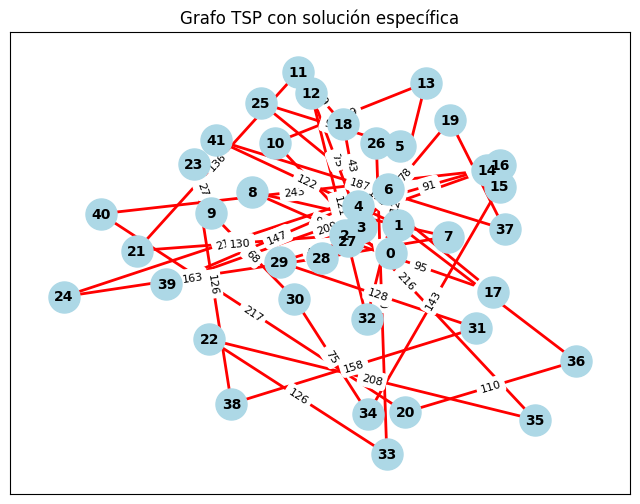

In [70]:
plot_tsp_solution(problem.edge_weights, crear_solucion(Nodos))

d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\Work\Cursos\IA\U_Valencia_Master_IA\03. Algoritmos de Optimización\Actividad Guiada 1 y 2\AG3\tsp_env\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


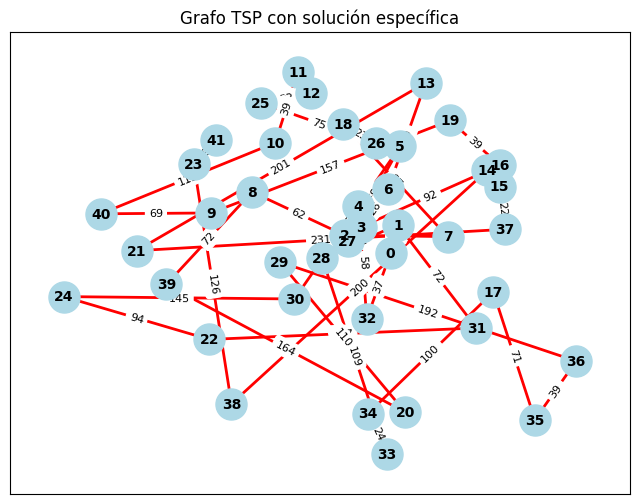

In [71]:
plot_tsp_solution(problem.edge_weights, solucion)